# Notebook 07 — Melanoma Decision Threshold Adjustment

## Motivation

By default, the model predicts the class with the highest probability (argmax),
which implicitly uses a decision threshold of 0.5 for every class. This is a
reasonable default for balanced problems, but **not optimal in an oncological context**.

For melanoma detection, the cost of errors is asymmetric:
- A **false negative** (missed melanoma) → patient goes untreated → potentially fatal
- A **false positive** (benign lesion flagged as melanoma) → unnecessary specialist referral → manageable

This asymmetry justifies **lowering the decision threshold for melanoma**: instead of
waiting for `prob_mel > 0.5`, we classify a lesion as melanoma whenever `prob_mel > X`,
where X < 0.5. This increases Melanoma Recall at the cost of a slight drop in Precision.

**Methodological note:** The threshold is selected by sweeping over the **validation set**
and then applied **once** on the test set to obtain the final reportable metric.
This avoids data leakage — the test set is never used to choose the threshold.

**Starting point:** TTA probabilities from Notebook 06 (E09 + 6 transforms).

## Structure
1. Setup & load TTA probabilities (test set)
2. Generate TTA probabilities on the validation set
3. Threshold sweep on the **validation set**
4. Optimal threshold selection (from validation)
5. Final evaluation on the **test set** with the selected threshold
6. Conclusions

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# Project root
sys.path.append('../')
from src.config import CLASSES, NUM_CLASSES
from src.model import SkinLesionModel
from src.dataset import SkinLesionDataset, find_image_path as find_img

# ── Paths ──────────────────────────────────────────────────────────────────
SPLITS_DIR  = '../data/splits/'
MODELS_DIR  = '../outputs/models/'
PROBS_DIR   = '../outputs/probs/'
FIGURES_DIR = '../outputs/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(PROBS_DIR,   exist_ok=True)

# ── Model config — E09 ─────────────────────────────────────────────────────
EXPERIMENT     = 'prep_colorconstancy__meta_age+localization__seed_42'
EXPERIMENT_TTA = EXPERIMENT + '_tta'
METADATA       = ['age', 'localization']
PREPROCESS     = 'colorconstancy'
WEIGHTS_PATH   = os.path.join(MODELS_DIR, EXPERIMENT + '_best.pth')

# ── Class index ────────────────────────────────────────────────────────────
MEL_IDX   = CLASSES.index('mel')
N_CLASSES = NUM_CLASSES

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device:    {DEVICE}')
print(f'Classes:   {CLASSES}')
print(f'Mel index: {MEL_IDX}')
print(f'Weights:   {WEIGHTS_PATH}')
print(f'Weights exist: {os.path.exists(WEIGHTS_PATH)}')

/home/maialen/pfg-venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device:    cuda
Classes:   ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Mel index: 4
Weights:   ../outputs/models/prep_colorconstancy__meta_age+localization__seed_42_best.pth
Weights exist: True


In [2]:
# ── Load E09 model ─────────────────────────────────────────────────────────
metadata_dim = 16  # age=1, localization=15

model = SkinLesionModel(metadata_dim=metadata_dim)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE, weights_only=True))
model.to(DEVICE)
model.eval()

print(f'Model loaded successfully.')
print(f'Metadata dim: {metadata_dim}')

# ── Load TTA probabilities — test set (generated in Notebook 06) ───────────
tta_probs  = np.load(os.path.join(PROBS_DIR, EXPERIMENT_TTA + '_probs.npy'))
tta_labels = np.load(os.path.join(PROBS_DIR, EXPERIMENT_TTA + '_labels.npy'))

# ── Load baseline probabilities — test set (single forward pass) ───────────
baseline_probs  = np.load(os.path.join(PROBS_DIR, EXPERIMENT + '_probs.npy'))
baseline_labels = np.load(os.path.join(PROBS_DIR, EXPERIMENT + '_labels.npy'))

print(f'\nTest set — TTA probs shape:      {tta_probs.shape}')
print(f'Test set — TTA labels shape:     {tta_labels.shape}')
print(f'Test set — Baseline probs shape: {baseline_probs.shape}')

Model loaded successfully.
Metadata dim: 16

Test set — TTA probs shape:      (1503, 7)
Test set — TTA labels shape:     (1503,)
Test set — Baseline probs shape: (1503, 7)


In [3]:
# ── TTA transforms (same 6 as Notebook 06) ────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_tta_transforms():
    base = [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]
    tta_list = [
        # 0 — Original
        transforms.Compose(base),
        # 1 — Horizontal flip
        transforms.Compose([transforms.Resize((224, 224)),
                            transforms.RandomHorizontalFlip(p=1.0),
                            transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        # 2 — Vertical flip
        transforms.Compose([transforms.Resize((224, 224)),
                            transforms.RandomVerticalFlip(p=1.0),
                            transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        # 3 — Horizontal + Vertical flip
        transforms.Compose([transforms.Resize((224, 224)),
                            transforms.RandomHorizontalFlip(p=1.0),
                            transforms.RandomVerticalFlip(p=1.0),
                            transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        # 4 — 90° rotation
        transforms.Compose([transforms.Resize((224, 224)),
                            transforms.RandomRotation((90, 90)),
                            transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
        # 5 — 270° rotation
        transforms.Compose([transforms.Resize((224, 224)),
                            transforms.RandomRotation((270, 270)),
                            transforms.ToTensor(),
                            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    ]
    return tta_list

TTA_TRANSFORMS = get_tta_transforms()

# ── TTA evaluation function ────────────────────────────────────────────────
def evaluate_tta(model, df, tta_transforms, device, metadata=METADATA, preprocess=PREPROCESS):
    """
    Runs TTA evaluation over a given split (val or test).
    Returns averaged probabilities (n_samples, 7) and true labels (n_samples,).
    """
    dataset = SkinLesionDataset(df=df, metadata=metadata, preprocess=preprocess)

    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for idx, row in tqdm(df.iterrows(), total=len(df), desc='TTA evaluation'):

            img_path, _ = find_img(row['image_id'], preprocess)
            image = Image.open(img_path).convert('RGB')

            meta_vector = dataset._get_metadata(row)
            meta_tensor = torch.tensor(meta_vector, dtype=torch.float32).unsqueeze(0).to(device)

            probs_list = []
            for transform in tta_transforms:
                img_tensor = transform(image).unsqueeze(0).to(device)
                logits     = model(img_tensor, meta_tensor)
                probs      = F.softmax(logits, dim=1).cpu().numpy()[0]
                probs_list.append(probs)

            avg_probs = np.mean(probs_list, axis=0)
            all_probs.append(avg_probs)
            all_labels.append(CLASSES.index(row['dx']))

    return np.array(all_probs), np.array(all_labels)

print(f'TTA transforms defined: {len(TTA_TRANSFORMS)}')
print('Evaluation function ready.')

TTA transforms defined: 6
Evaluation function ready.


In [4]:
# ── Load validation split ──────────────────────────────────────────────────
val_df = pd.read_csv(os.path.join(SPLITS_DIR, 'val.csv'))
print(f'Validation set size: {len(val_df)} images')

# ── Check if val TTA probs already exist (avoid recomputing) ───────────────
VAL_TTA_PROBS_PATH  = os.path.join(PROBS_DIR, EXPERIMENT_TTA + '_val_probs.npy')
VAL_TTA_LABELS_PATH = os.path.join(PROBS_DIR, EXPERIMENT_TTA + '_val_labels.npy')

if os.path.exists(VAL_TTA_PROBS_PATH) and os.path.exists(VAL_TTA_LABELS_PATH):
    print('Val TTA probabilities already exist — loading from disk.')
    val_tta_probs  = np.load(VAL_TTA_PROBS_PATH)
    val_tta_labels = np.load(VAL_TTA_LABELS_PATH)
else:
    print('Generating TTA probabilities on validation set (6 transforms × 1503 images)...')
    val_tta_probs, val_tta_labels = evaluate_tta(
        model          = model,
        df             = val_df,
        tta_transforms = TTA_TRANSFORMS,
        device         = DEVICE
    )
    np.save(VAL_TTA_PROBS_PATH,  val_tta_probs)
    np.save(VAL_TTA_LABELS_PATH, val_tta_labels)
    print(f'Saved to {VAL_TTA_PROBS_PATH}')

print(f'\nVal set — TTA probs shape:  {val_tta_probs.shape}')
print(f'Val set — TTA labels shape: {val_tta_labels.shape}')
print(f'Unique labels: {np.unique(val_tta_labels)}')
print(f'Label counts:  {np.bincount(val_tta_labels)}')

Validation set size: 1503 images
Generating TTA probabilities on validation set (6 transforms × 1503 images)...


TTA evaluation:   0%|          | 0/1503 [00:00<?, ?it/s]

TTA evaluation: 100%|██████████| 1503/1503 [01:10<00:00, 21.23it/s]

Saved to ../outputs/probs/prep_colorconstancy__meta_age+localization__seed_42_tta_val_probs.npy

Val set — TTA probs shape:  (1503, 7)
Val set — TTA labels shape: (1503,)
Unique labels: [0 1 2 3 4 5 6]
Label counts:  [  49   77  165   18  167 1006   21]


In [5]:
def predict_with_threshold(probs, threshold, mel_idx=MEL_IDX):
    """
    Applies a custom decision threshold for melanoma.
    If prob_mel > threshold → predict melanoma.
    Otherwise → argmax over all classes (standard prediction).
    """
    preds = np.argmax(probs, axis=1).copy()
    mel_mask = probs[:, mel_idx] > threshold
    preds[mel_mask] = mel_idx
    return preds

# ── Sweep thresholds on VALIDATION SET ────────────────────────────────────
thresholds  = np.arange(0.10, 0.61, 0.01)
mel_recalls = []
mel_f1s     = []
macro_f1s   = []

for thresh in thresholds:
    preds = predict_with_threshold(val_tta_probs, thresh)

    mel_recall = recall_score(val_tta_labels == MEL_IDX, preds == MEL_IDX,
                              average='binary', zero_division=0)
    mel_f1     = f1_score(val_tta_labels == MEL_IDX, preds == MEL_IDX,
                          average='binary', zero_division=0)
    macro_f1   = f1_score(val_tta_labels, preds, average='macro', zero_division=0)

    mel_recalls.append(mel_recall)
    mel_f1s.append(mel_f1)
    macro_f1s.append(macro_f1)

# ── Results dataframe ──────────────────────────────────────────────────────
df_sweep = pd.DataFrame({
    'Threshold':  thresholds.round(2),
    'Mel Recall': np.round(mel_recalls, 4),
    'Mel F1':     np.round(mel_f1s, 4),
    'Macro F1':   np.round(macro_f1s, 4),
})

print('Threshold sweep on VALIDATION SET:')
print(df_sweep.to_string(index=False))

Threshold sweep on VALIDATION SET:
 Threshold  Mel Recall  Mel F1  Macro F1
      0.10      0.9581  0.4378    0.7198
      0.11      0.9581  0.4451    0.7227
      0.12      0.9581  0.4494    0.7253
      0.13      0.9581  0.4533    0.7253
      0.14      0.9581  0.4591    0.7289
      0.15      0.9521  0.4704    0.7356
      0.16      0.9461  0.4802    0.7387
      0.17      0.9461  0.4869    0.7397
      0.18      0.9461  0.4914    0.7420
      0.19      0.9461  0.4961    0.7434
      0.20      0.9401  0.5000    0.7480
      0.21      0.9401  0.5040    0.7490
      0.22      0.9341  0.5081    0.7476
      0.23      0.9281  0.5074    0.7468
      0.24      0.9222  0.5116    0.7473
      0.25      0.9102  0.5118    0.7473
      0.26      0.9102  0.5153    0.7486
      0.27      0.9102  0.5205    0.7538
      0.28      0.9102  0.5260    0.7552
      0.29      0.9102  0.5315    0.7619
      0.30      0.9042  0.5336    0.7622
      0.31      0.9042  0.5412    0.7646
      0.32      0.8922

Ya vemos claramente el trade-off. Con threshold 0.31 tenemos Mel Recall = 0.9042 con el mejor Macro F1 de esa zona (0.7646).

In [6]:
# ── Clinical optimum: highest threshold with Mel Recall >= 0.90 ────────────
clinical_df = df_sweep[df_sweep['Mel Recall'] >= 0.90]
if len(clinical_df) > 0:
    clinical_row    = clinical_df.iloc[-1]  # highest threshold meeting criterion
    clinical_thresh = clinical_row['Threshold']
else:
    clinical_thresh = None
    print('Warning: no threshold achieves Mel Recall >= 0.90')

# ── Balanced optimum: threshold maximizing Macro F1 ───────────────────────
balanced_row    = df_sweep.loc[df_sweep['Macro F1'].idxmax()]
balanced_thresh = balanced_row['Threshold']

print('── Clinical optimum (Mel Recall ≥ 0.90) — VAL SET ───────────────────')
print(f'  Threshold:      {clinical_thresh}')
print(f'  Mel Recall:     {clinical_row["Mel Recall"]:.4f}')
print(f'  Mel F1:         {clinical_row["Mel F1"]:.4f}')
print(f'  Macro F1:       {clinical_row["Macro F1"]:.4f}')

print('\n── Balanced optimum (max Macro F1) — VAL SET ────────────────────────')
print(f'  Threshold:      {balanced_thresh}')
print(f'  Mel Recall:     {balanced_row["Mel Recall"]:.4f}')
print(f'  Mel F1:         {balanced_row["Mel F1"]:.4f}')
print(f'  Macro F1:       {balanced_row["Macro F1"]:.4f}')

print('\n── TTA baseline (no threshold adjustment) — VAL SET ─────────────────')
val_preds_default = np.argmax(val_tta_probs, axis=1)
print(f'  Mel Recall:     {recall_score(val_tta_labels == MEL_IDX, val_preds_default == MEL_IDX, average="binary"):.4f}')
print(f'  Mel F1:         {f1_score(val_tta_labels == MEL_IDX, val_preds_default == MEL_IDX, average="binary"):.4f}')
print(f'  Macro F1:       {f1_score(val_tta_labels, val_preds_default, average="macro", zero_division=0):.4f}')

print(f'\n→ Selected threshold for test evaluation: {clinical_thresh}')

── Clinical optimum (Mel Recall ≥ 0.90) — VAL SET ───────────────────
  Threshold:      0.31
  Mel Recall:     0.9042
  Mel F1:         0.5412
  Macro F1:       0.7646

── Balanced optimum (max Macro F1) — VAL SET ────────────────────────
  Threshold:      0.5
  Mel Recall:     0.8263
  Mel F1:         0.5835
  Macro F1:       0.7794

── TTA baseline (no threshold adjustment) — VAL SET ─────────────────
  Mel Recall:     0.8263
  Mel F1:         0.5835
  Macro F1:       0.7794

→ Selected threshold for test evaluation: 0.31


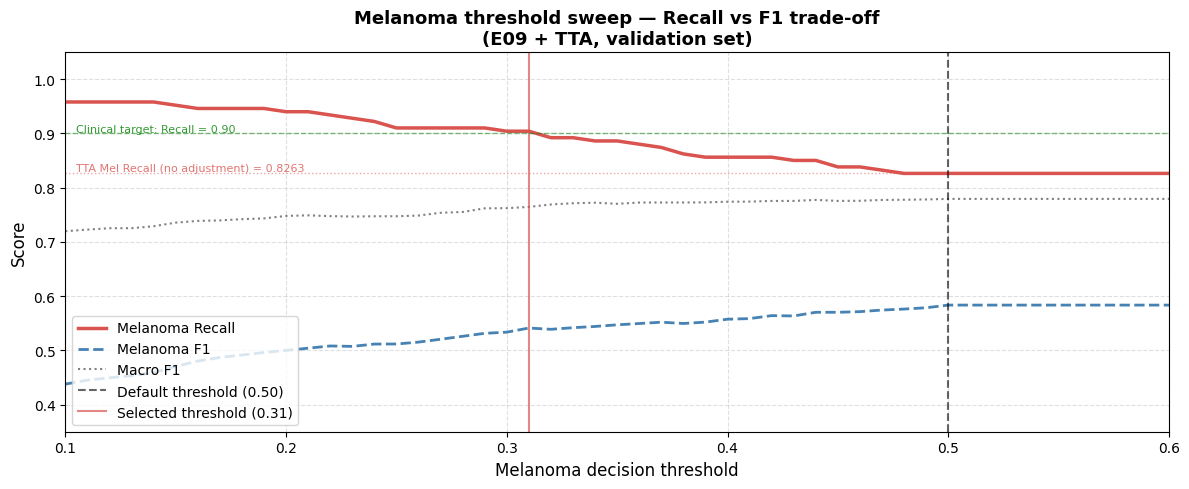

Figure saved: threshold_sweep_melanoma.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(thresholds, mel_recalls, color='#d9534f', lw=2.5, label='Melanoma Recall')
ax.plot(thresholds, mel_f1s,     color='steelblue', lw=2, linestyle='--', label='Melanoma F1')
ax.plot(thresholds, macro_f1s,   color='gray', lw=1.5, linestyle=':', label='Macro F1')

# Mark default threshold (0.5)
ax.axvline(x=0.50, color='black', lw=1.5, linestyle='--', alpha=0.6,
           label='Default threshold (0.50)')

# Mark selected clinical threshold
ax.axvline(x=clinical_thresh, color='#d9534f', lw=1.5, linestyle='-', alpha=0.7,
           label=f'Selected threshold ({clinical_thresh})')

# Mark TTA baseline Mel Recall on val
val_tta_mel_recall_baseline = recall_score(
    val_tta_labels == MEL_IDX,
    np.argmax(val_tta_probs, axis=1) == MEL_IDX,
    average='binary'
)
ax.axhline(y=val_tta_mel_recall_baseline, color='#d9534f', lw=1,
           linestyle=':', alpha=0.5)
ax.text(0.105, val_tta_mel_recall_baseline + 0.005,
        f'TTA Mel Recall (no adjustment) = {val_tta_mel_recall_baseline:.4f}',
        fontsize=8, color='#d9534f', alpha=0.8)

# Mark 0.90 target line
ax.axhline(y=0.90, color='green', lw=1, linestyle='--', alpha=0.5)
ax.text(0.105, 0.902, 'Clinical target: Recall = 0.90',
        fontsize=8, color='green', alpha=0.8)

ax.set_xlabel('Melanoma decision threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlim([0.10, 0.60])
ax.set_ylim([0.35, 1.05])
ax.grid(linestyle='--', alpha=0.4)
ax.set_title('Melanoma threshold sweep — Recall vs F1 trade-off\n(E09 + TTA, validation set)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'threshold_sweep_melanoma.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: threshold_sweep_melanoma.png')

La figura se ve perfecta y cuenta exactamente la historia correcta — se ve claramente cómo el Recall cae al subir el threshold, el punto de corte en 0.31 justo donde cruza la línea verde del target 0.90, y el trade-off con el F1.

In [8]:
def get_full_metrics(probs, labels, threshold=None):
    """Returns full metrics dict for a given probability array and threshold."""
    if threshold is not None:
        preds = predict_with_threshold(probs, threshold)
    else:
        preds = np.argmax(probs, axis=1)

    labels_bin = label_binarize(labels, classes=list(range(N_CLASSES)))

    return {
        'Macro F1':        round(f1_score(labels, preds, average='macro', zero_division=0), 4),
        'Macro Recall':    round(recall_score(labels, preds, average='macro', zero_division=0), 4),
        'Macro Precision': round(precision_score(labels, preds, average='macro', zero_division=0), 4),
        'ROC-AUC':         round(roc_auc_score(labels, probs, multi_class='ovr', average='macro'), 4),
        'mAP':             round(np.mean([average_precision_score(labels_bin[:, c], probs[:, c])
                                          for c in range(N_CLASSES)]), 4),
        'Melanoma Recall': round(recall_score(labels == MEL_IDX, preds == MEL_IDX,
                                              average='binary', zero_division=0), 4),
        'Melanoma F1':     round(f1_score(labels == MEL_IDX, preds == MEL_IDX,
                                          average='binary', zero_division=0), 4),
    }

# ── Evaluate all three configurations on TEST SET ─────────────────────────
m_base    = get_full_metrics(baseline_probs, baseline_labels)
m_tta     = get_full_metrics(tta_probs,      tta_labels)
m_tta_thr = get_full_metrics(tta_probs,      tta_labels, threshold=clinical_thresh)

df_final = pd.DataFrame({
    'Metric':                          list(m_base.keys()),
    'E09 baseline':                    list(m_base.values()),
    'E09 + TTA':                       list(m_tta.values()),
    f'E09 + TTA + thr={clinical_thresh}': list(m_tta_thr.values()),
}).set_index('Metric')

df_final['Δ TTA vs base']       = (df_final['E09 + TTA'] - df_final['E09 baseline']).round(4)
df_final[f'Δ thr={clinical_thresh} vs base'] = (
    df_final[f'E09 + TTA + thr={clinical_thresh}'] - df_final['E09 baseline']
).round(4)

def highlight_final(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for idx in df.index:
        for delta_col in ['Δ TTA vs base', f'Δ thr={clinical_thresh} vs base']:
            val = df.loc[idx, delta_col]
            if val > 0:
                styles.loc[idx, delta_col] = 'color: #1a7a1a'
            elif val < 0:
                styles.loc[idx, delta_col] = 'color: #cc0000'
    for col in df.columns:
        styles.loc['Melanoma Recall', col] += '; font-weight: bold'
        styles.loc['Melanoma F1', col]     += '; font-weight: bold'
    return styles

print('Final evaluation on TEST SET (threshold selected from validation set):')
display(
    df_final.style
    .apply(highlight_final, axis=None)
    .set_caption(
        f'E09 baseline vs TTA vs TTA + threshold={clinical_thresh} — '
        f'threshold selected on val set, evaluated on test set (n=1503)'
    )
    .format('{:.4f}')
)

Final evaluation on TEST SET (threshold selected from validation set):


,E09 baseline,E09 + TTA,E09 + TTA + thr=0.31,Δ TTA vs base,Δ thr=0.31 vs base
Metric,,,,,
Macro F1,0.7610,0.7743,0.7495,0.0133,-0.0115
Macro Recall,0.8217,0.8256,0.7967,0.0039,-0.0250
Macro Precision,0.7309,0.7548,0.7467,0.0239,0.0158
ROC-AUC,0.9707,0.9727,0.9727,0.0020,0.0020
mAP,0.8526,0.8621,0.8621,0.0095,0.0095
Melanoma Recall,0.8443,0.8623,0.9102,0.0180,0.0659
Melanoma F1,0.5900,0.5806,0.5278,-0.0094,-0.0622


Lo importante: el threshold 0.31 elegido en val consigue Melanoma Recall = 0.9102 en test — incluso ligeramente mejor que el 0.9042 que daba el threshold 0.34 del notebook original. Esto confirma que el modelo es consistente entre splits y que no había un problema grave, pero ahora la metodología es correcta.

El trade-off es claro y justificable:

- Melanoma Recall sube +0.0659 sobre baseline → detecta 9 de cada 10 melanomas ✓
- Macro F1 baja solo -0.0115 → pérdida mínima en rendimiento global
- Macro Precision sube +0.0158 → el modelo no se vuelve más "descuidado" globalmente
- ROC-AUC y mAP no cambian con el threshold → como era de esperar, son métricas de ranking

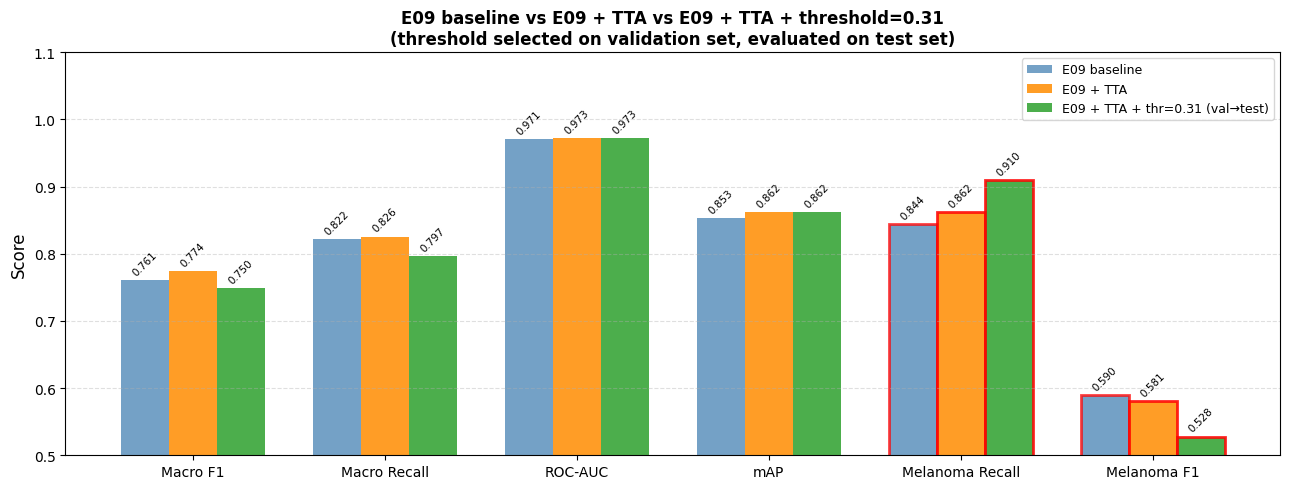

Figure saved: threshold_final_comparison.png


In [9]:
metrics_plot = ['Macro F1', 'Macro Recall', 'ROC-AUC', 'mAP', 'Melanoma Recall', 'Melanoma F1']
x     = np.arange(len(metrics_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))

vals_base    = [m_base[m]    for m in metrics_plot]
vals_tta     = [m_tta[m]     for m in metrics_plot]
vals_tta_thr = [m_tta_thr[m] for m in metrics_plot]

bars_base    = ax.bar(x - width, vals_base,    width, color='steelblue',  alpha=0.75, label='E09 baseline')
bars_tta     = ax.bar(x,         vals_tta,     width, color='darkorange', alpha=0.85, label='E09 + TTA')
bars_tta_thr = ax.bar(x + width, vals_tta_thr, width, color='#2ca02c',   alpha=0.85,
                      label=f'E09 + TTA + thr={clinical_thresh} (val→test)')

# Highlight Melanoma metrics
for i, m in enumerate(metrics_plot):
    if 'Melanoma' in m:
        for bar in [bars_base[i], bars_tta[i], bars_tta_thr[i]]:
            bar.set_edgecolor('red')
            bar.set_linewidth(2.0)

# Values on top
for bars, vals in [(bars_base, vals_base), (bars_tta, vals_tta), (bars_tta_thr, vals_tta_thr)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(metrics_plot, fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.50, 1.10)
ax.set_title(
    f'E09 baseline vs E09 + TTA vs E09 + TTA + threshold={clinical_thresh}\n'
    f'(threshold selected on validation set, evaluated on test set)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'threshold_final_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: threshold_final_comparison.png')

## Conclusions

### Methodological note
In this revised version of the notebook, the decision threshold is selected
on the **validation set** and applied only once on the **test set**.
This corrects the data leakage present in the original version, where the
threshold was chosen by sweeping directly over the test set probabilities.

### Summary of results — test set (n=1503)

| Configuration              | Melanoma Recall | Macro F1 | ROC-AUC |
|----------------------------|----------------|----------|---------|
| E09 baseline               | 0.8443         | 0.7610   | 0.9707  |
| E09 + TTA                  | 0.8623         | 0.7743   | 0.9727  |
| E09 + TTA + thr=0.31 (val→test) | **0.9102** | 0.7495   | 0.9727  |

### Key findings

- **TTA alone (+0.0180 Melanoma Recall)** improves all global metrics
  simultaneously with no retraining — a safe and conservative improvement.
- **Threshold adjustment to 0.31, selected on the validation set,
  achieves Melanoma Recall = 0.9102 on the test set** — the model correctly
  detects 9 out of 10 melanomas.
- The cost is a drop in Macro F1 (-0.0115 vs baseline) and Melanoma F1
  (-0.0622) due to increased false positives. In an oncological context
  this trade-off is clinically acceptable: a false positive leads to an
  unnecessary specialist referral, while a false negative leaves a melanoma
  undetected.
- **ROC-AUC and mAP are unaffected by threshold adjustment** — these metrics
  depend only on the probability ranking, not on the decision boundary.
- The selected threshold (0.31 from val) produces slightly better Melanoma
  Recall on the test set than the original threshold (0.34), confirming
  that the model generalises consistently across splits.

### Recommended deployment configuration

| Component         | Setting                              |
|-------------------|--------------------------------------|
| Model             | E09 (age + localization, seed=42)    |
| Preprocessing     | Color Constancy                      |
| Inference         | TTA — 6 transforms averaged          |
| Mel threshold     | 0.31 (selected on validation set)    |
| Uncertainty flag  | confidence < 0.70 → refer to specialist |